# EDA - features and target for the reject-effectiveness model

Before training anything: check that the target has real variance (not
99% one class), and that each candidate feature actually differs between
the two outcomes -- if a feature looks identical whether reject worked or
not, it won't help the model.

In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('../clean_data/dataset_completed_clean.csv')
print('Full shape:', df.shape)

Full shape: (4100, 31)


## Step 1 - Filter to the subset where the differential test ran

In [2]:
df_model = df[df['reject_click_attempted'] == True].copy()
print(f'Rows with a usable differential test: {len(df_model)} / {len(df)}')

Rows with a usable differential test: 1583 / 4100


## Step 2 - Build and check the target
This is the single most important check before anything else: is the
split reasonably balanced, or is one class so rare the model could just
predict the majority every time and look 'accurate'?

In [3]:
df_model['reject_works'] = df_model['tracker_count_after_reject'] == 0

print(df_model['reject_works'].value_counts())
print()
print(df_model['reject_works'].value_counts(normalize=True).round(3) * 100)

reject_works
False    899
True     684
Name: count, dtype: int64

reject_works
False    56.8
True     43.2
Name: proportion, dtype: float64


## Step 3 - Build the derived hosting feature

In [4]:
MAJOR_CLOUD_CDN = ['amazon', 'google', 'fastly', 'akamai', 'cloudflare', 'microsoft']

def is_major_cloud_cdn(org):
    if pd.isna(org):
        return False
    org_lower = org.lower()
    return any(name in org_lower for name in MAJOR_CLOUD_CDN)

df_model['uses_major_cloud_cdn'] = df_model['org'].apply(is_major_cloud_cdn)
print(df_model['uses_major_cloud_cdn'].value_counts(dropna=False))

uses_major_cloud_cdn
False    993
True     590
Name: count, dtype: int64


## Step 4 - Null check on ALL candidate features, within this subset
Nulls behave differently once filtered to this smaller subset -- re-check
rather than assume the full-dataset percentages still apply.

In [5]:
feature_cols = [
    'cmp_detected', 'tracker_count', 'ad_network_count',
    'cookies_before_interaction', 'non_essential_cookies_before_interaction',
    'long_lived_cookies_count', 'has_privacy_policy',
    'is_hosting', 'uses_major_cloud_cdn'
]

null_pct = (df_model[feature_cols].isnull().sum() / len(df_model) * 100).sort_values(ascending=False)
print(null_pct.round(1))

has_privacy_policy                          0.2
is_hosting                                  0.2
cmp_detected                                0.0
tracker_count                               0.0
ad_network_count                            0.0
cookies_before_interaction                  0.0
non_essential_cookies_before_interaction    0.0
long_lived_cookies_count                    0.0
uses_major_cloud_cdn                        0.0
dtype: float64


## Step 5 - Numeric features: do they actually differ by outcome?
Groups by reject_works (True/False), shows mean/median for each numeric
feature. A useful feature should show a visible difference between groups.

In [6]:
numeric_features = ['tracker_count', 'ad_network_count', 'cookies_before_interaction',
                     'non_essential_cookies_before_interaction', 'long_lived_cookies_count']

print(df_model.groupby('reject_works')[numeric_features].mean().round(2))
print()
print(df_model.groupby('reject_works')[numeric_features].median().round(2))

              tracker_count  ad_network_count  cookies_before_interaction  non_essential_cookies_before_interaction  long_lived_cookies_count
reject_works                                                                                                                                 
False                 18.89              9.37                        8.37                                      7.58                      1.54
True                  11.44              4.25                        5.61                                      5.00                      1.12

              tracker_count  ad_network_count  cookies_before_interaction  non_essential_cookies_before_interaction  long_lived_cookies_count
reject_works                                                                                                                                 
False                  16.0               7.0                         6.0                                       5.0                       1.0
True 

## Step 6 - Categorical/boolean features: do they differ by outcome?

In [7]:
bool_features = ['has_privacy_policy', 'is_hosting', 'uses_major_cloud_cdn']

for col in bool_features:
    print(f'--- {col} ---')
    print(pd.crosstab(df_model[col], df_model['reject_works'], normalize='index').round(3))
    print()

--- has_privacy_policy ---
reject_works        False  True 
has_privacy_policy              
False               0.580  0.420
True                0.566  0.434

--- is_hosting ---
reject_works  False  True 
is_hosting                
False         0.493  0.507
True          0.598  0.402

--- uses_major_cloud_cdn ---
reject_works          False  True 
uses_major_cloud_cdn              
False                 0.533  0.467
True                  0.627  0.373



## Step 7 - cmp_detected: reject-works rate by vendor
This is likely your strongest feature -- check it's not just noise from
vendors with only 1-2 sites each.

In [8]:
cmp_summary = df_model.groupby('cmp_detected').agg(
    n_sites=('reject_works', 'count'),
    pct_reject_works=('reject_works', 'mean')
).sort_values('n_sites', ascending=False)

cmp_summary['pct_reject_works'] = (cmp_summary['pct_reject_works'] * 100).round(1)
print(cmp_summary)

                n_sites  pct_reject_works
cmp_detected                             
none                576              61.3
onetrust            387              11.1
didomi              132              39.4
usercentrics         95              80.0
trustarc             66              47.0
cookiebot            64               7.8
sourcepoint          54              59.3
iubenda              51              29.4
cookie notice        36              13.9
cookieyes            28              85.7
trustcommander       23              56.5
complianz            15              60.0
quantcast            14              35.7
klaro                10              80.0
osano                10              20.0
fundingchoices       10              10.0
axeptio               8              87.5
commanders act        3              66.7
setupad               1             100.0


## Step 8 - Distribution shape of tracker_count (before)
Check for skew/outliers that might need a log transform or capping later.

In [9]:
print(df_model['tracker_count'].describe())
print()
print('Top 5 highest tracker_count rows:')
print(df_model.nlargest(5, 'tracker_count')[['url', 'tracker_count', 'reject_works']])

count    1583.000000
mean       15.674668
std        11.660968
min         1.000000
25%         8.000000
50%        12.000000
75%        20.000000
max       114.000000
Name: tracker_count, dtype: float64

Top 5 highest tracker_count rows:
                         url  tracker_count  reject_works
3378     https://wowhead.com          114.0         False
3957      https://sfgate.com           96.0         False
3114        https://ndtv.com           93.0         False
887   https://fcinter1908.it           86.0          True
3296    https://cricbuzz.com           82.0         False


## Check 1 - Why does 'none' (no recognized CMP) still work 61.3% of the time?
Compare the 'none' group's tracker_count against the rest -- if it's
mostly low-tracker sites, that explains the decent success rate without
needing a CMP vendor at all (custom banners on simple sites).

In [10]:
df_none = df_model[df_model['cmp_detected'] == 'none']
df_known_cmp = df_model[df_model['cmp_detected'] != 'none']

print('=== "none" group (n=%d) ===' % len(df_none))
print(df_none[['tracker_count', 'ad_network_count']].describe().round(2))
print()
print('=== known CMP group (n=%d) ===' % len(df_known_cmp))
print(df_known_cmp[['tracker_count', 'ad_network_count']].describe().round(2))

=== "none" group (n=576) ===
       tracker_count  ad_network_count
count         576.00            576.00
mean           11.54              5.22
std            10.10              6.91
min             1.00              0.00
25%             5.00              1.00
50%             9.00              3.00
75%            14.00              6.00
max            96.00             71.00

=== known CMP group (n=1007) ===
       tracker_count  ad_network_count
count        1007.00           1007.00
mean           18.04              8.27
std            11.84              8.07
min             1.00              0.00
25%            10.00              3.00
50%            15.00              6.00
75%            23.00             11.00
max           114.00             67.00


In [11]:
print('Median tracker_count, none vs known CMP:')
print('  none:      ', df_none['tracker_count'].median())
print('  known CMP: ', df_known_cmp['tracker_count'].median())
print()
print('reject_works rate, none vs known CMP:')
print('  none:      ', (df_none['reject_works'].mean() * 100).round(1), '%')
print('  known CMP: ', (df_known_cmp['reject_works'].mean() * 100).round(1), '%')

Median tracker_count, none vs known CMP:
  none:       9.0
  known CMP:  15.0

reject_works rate, none vs known CMP:
  none:       61.3 %
  known CMP:  32.9 %


## Check 2 - Correlation between numeric features
If tracker_count and ad_network_count move almost perfectly together,
one may be redundant (though RandomForest tolerates this fine either way).

In [12]:
numeric_features = ['tracker_count', 'ad_network_count', 'cookies_before_interaction',
                     'non_essential_cookies_before_interaction', 'long_lived_cookies_count']

corr_matrix = df_model[numeric_features].corr().round(2)
print(corr_matrix)

                                          tracker_count  ad_network_count  cookies_before_interaction  non_essential_cookies_before_interaction  long_lived_cookies_count
tracker_count                                      1.00              0.93                        0.50                                      0.50                      0.47
ad_network_count                                   0.93              1.00                        0.45                                      0.45                      0.42
cookies_before_interaction                         0.50              0.45                        1.00                                      0.99                      0.65
non_essential_cookies_before_interaction           0.50              0.45                        0.99                                      1.00                      0.66
long_lived_cookies_count                           0.47              0.42                        0.65                                      0.66       

## Check 3 - Within OneTrust specifically: is low success rate about the
vendor itself, or just that OneTrust sites tend to have more trackers?
Compare tracker_count for OneTrust's True vs False rows -- if it still
shows a gap, tracker_count matters even within the same vendor (both
effects are real, independently).

In [13]:
df_onetrust = df_model[df_model['cmp_detected'] == 'onetrust']

print('OneTrust sites where reject WORKED (n=%d):' % (df_onetrust['reject_works'] == True).sum())
print(df_onetrust[df_onetrust['reject_works'] == True]['tracker_count'].describe().round(2))
print()
print('OneTrust sites where reject did NOT work (n=%d):' % (df_onetrust['reject_works'] == False).sum())
print(df_onetrust[df_onetrust['reject_works'] == False]['tracker_count'].describe().round(2))

OneTrust sites where reject WORKED (n=43):
count    43.00
mean     11.79
std       6.35
min       4.00
25%       7.50
50%      11.00
75%      14.00
max      30.00
Name: tracker_count, dtype: float64

OneTrust sites where reject did NOT work (n=344):
count    344.00
mean      18.38
std       12.07
min        3.00
25%       11.00
50%       14.50
75%       23.00
max      114.00
Name: tracker_count, dtype: float64


## Check 3b - Same comparison for a HIGH-performing vendor (CookieYes)
as a point of contrast.

In [14]:
df_cookieyes = df_model[df_model['cmp_detected'] == 'cookieyes']

print('CookieYes sites where reject WORKED (n=%d):' % (df_cookieyes['reject_works'] == True).sum())
print(df_cookieyes[df_cookieyes['reject_works'] == True]['tracker_count'].describe().round(2))
print()
print('CookieYes sites where reject did NOT work (n=%d):' % (df_cookieyes['reject_works'] == False).sum())
print(df_cookieyes[df_cookieyes['reject_works'] == False]['tracker_count'].describe().round(2))

CookieYes sites where reject WORKED (n=24):
count    24.00
mean     12.92
std       5.35
min       3.00
25%       8.75
50%      13.00
75%      16.25
max      23.00
Name: tracker_count, dtype: float64

CookieYes sites where reject did NOT work (n=4):
count     4.00
mean     25.75
std      13.67
min      16.00
25%      19.00
50%      20.50
75%      27.25
max      46.00
Name: tracker_count, dtype: float64


# Figures for the report

Everything above is analysis I ran to decide what to model. This last part turns
the parts that carry a finding into charts I can drop straight into the report
and the deck.

Design rules I stuck to so they look like one set:
- one accent hue, light -> dark, when the bar length already carries the meaning
- red/blue only where two categories genuinely oppose each other
- the value printed on the bar, so nobody has to read a gridline
- `n=` on every group, because a percentage with no denominator is not a finding

They save to `../docs/figures/`.

In [15]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

OUT = '../docs/figures'
os.makedirs(OUT, exist_ok=True)

# palette
BLUE, ORANGE, VIOLET = '#2a78d6', '#eb6834', '#4a3aa7'
GREEN, RED = '#008300', '#e34948'
INK, INK2, GRID = '#0b0b0b', '#52514e', '#e3e3e0'

# one sequential ramp, reused everywhere a bar means "more"
RAMP = matplotlib.colors.LinearSegmentedColormap.from_list('b', ['#bcd6f2', '#1b5aa5'])

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.size': 9, 'axes.edgecolor': GRID, 'axes.labelcolor': INK2,
    'text.color': INK, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.titlesize': 10.5, 'axes.titleweight': 'bold', 'axes.titlecolor': INK,
    'savefig.dpi': 200, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
})


def style(ax, xgrid=False, ygrid=False):
    """Drop the top/right spines and put a faint grid behind the bars."""
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(GRID)
    ax.tick_params(length=0)
    if xgrid:
        ax.xaxis.grid(True, color=GRID, lw=0.7)
    if ygrid:
        ax.yaxis.grid(True, color=GRID, lw=0.7)
    ax.set_axisbelow(True)


def label_h(ax, bars, vals, fmt='{:.0f}'):
    """Value at the end of each horizontal bar."""
    pad = max(vals) * 0.015
    for b, v in zip(bars, vals):
        ax.text(b.get_width() + pad, b.get_y() + b.get_height() / 2,
                fmt.format(v), va='center', fontsize=8.5, color=INK)


def label_v(ax, bars, vals, fmt='{:.0f}'):
    """Value on top of each vertical bar."""
    pad = max(vals) * 0.02
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + pad,
                fmt.format(v), ha='center', va='bottom', fontsize=8.5, color=INK)


def save(fig, name):
    fig.savefig(f'{OUT}/{name}.png')
    print('saved', name)


print('figure setup ready — using df_model:', df_model.shape)

figure setup ready — using df_model: (1583, 33)


## Figure 1 - Target balance

The check from Step 2, as a chart. Red/blue is justified here: the two classes
genuinely oppose each other.

saved f01_target_balance


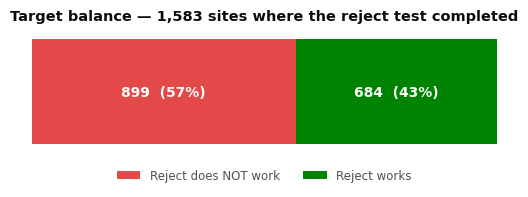

In [16]:
counts = df_model['reject_works'].value_counts()
n_no, n_yes = int(counts.get(False, 0)), int(counts.get(True, 0))
tot = n_no + n_yes

fig, ax = plt.subplots(figsize=(6.0, 1.5))
ax.barh([0], [n_no], color=RED, height=.55, label='Reject does NOT work')
ax.barh([0], [n_yes], left=[n_no], color=GREEN, height=.55, label='Reject works')

ax.text(n_no / 2, 0, f'{n_no:,}  ({n_no/tot*100:.0f}%)', ha='center', va='center',
        color='white', fontsize=10, fontweight='bold')
ax.text(n_no + n_yes / 2, 0, f'{n_yes:,}  ({n_yes/tot*100:.0f}%)', ha='center',
        va='center', color='white', fontsize=10, fontweight='bold')

ax.set_xlim(0, tot); ax.set_yticks([]); ax.set_xticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title(f'Target balance — {tot:,} sites where the reject test completed', pad=10)
ax.legend(loc='upper center', bbox_to_anchor=(.5, -.08), ncol=2, frameon=False,
          fontsize=8.5, labelcolor=INK2)
save(fig, 'f01_target_balance')

## Figure 2 - Reject effectiveness vs how much a site tracks you first

Step 5 showed the group means differ. This shows the *shape* of that difference,
which is much more convincing: bucket sites by pre-consent tracker count and plot
the share where reject actually worked. If it declines steadily rather than
jumping around, it's real signal and not two means that happen to differ.

                size  mean
tracker_bucket            
0–2               34  94.1
3–5              176  72.2
6–9              318  57.9
10–14            407  45.9
15–19            220  33.2
20–29            272  19.1
30+              156  18.6
saved f03_reject_by_tracker_load


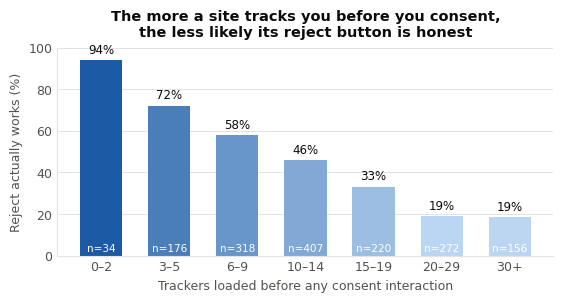

In [17]:
edges = [0, 3, 6, 10, 15, 20, 30, 10_000]
names = ['0–2', '3–5', '6–9', '10–14', '15–19', '20–29', '30+']

df_model['tracker_bucket'] = pd.cut(df_model['tracker_count'], bins=edges,
                                    labels=names, right=False)
g = df_model.groupby('tracker_bucket', observed=True)['reject_works'].agg(['size', 'mean'])
g['mean'] *= 100
print(g.round(1))

fig, ax = plt.subplots(figsize=(6.4, 2.7))
shade = (g['mean'] - g['mean'].min()) / max(g['mean'].max() - g['mean'].min(), 1e-9)
bars = ax.bar(range(len(g)), g['mean'], width=.62, color=[RAMP(v) for v in shade])
label_v(ax, bars, g['mean'].values, '{:.0f}%')

for i, n in enumerate(g['size']):
    ax.text(i, 2, f'n={int(n)}', ha='center', fontsize=7.5, color='white')

ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index)
ax.set_ylim(0, 100)
ax.set_xlabel('Trackers loaded before any consent interaction')
ax.set_ylabel('Reject actually works (%)')
ax.set_title('The more a site tracks you before you consent,\nthe less likely its reject button is honest', pad=8)
style(ax, ygrid=True)
save(fig, 'f03_reject_by_tracker_load')

## Figure 3 - Reject effectiveness by CMP vendor

Step 7 as a chart, keeping the `n >= 50` cutoff so I'm not plotting a vendor with
three sites next to one with four hundred. The `n=` on each label is doing real
work here.

                n   pct
cmp_detected           
cookiebot      64   7.8
onetrust      387  11.1
iubenda        51  29.4
didomi        132  39.4
trustarc       66  47.0
sourcepoint    54  59.3
none          576  61.3
usercentrics   95  80.0
saved f02_reject_by_cmp


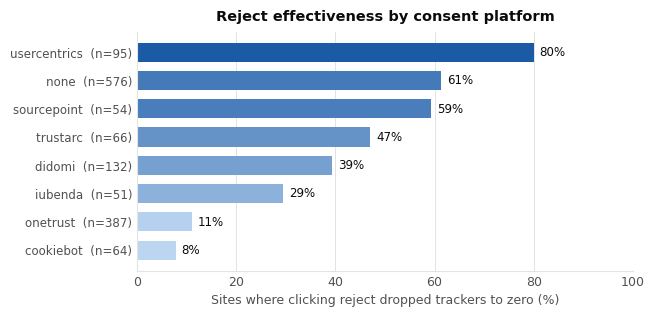

In [18]:
eff = (df_model.groupby('cmp_detected')
       .agg(n=('reject_works', 'size'), pct=('reject_works', 'mean'))
       .query('n >= 50').sort_values('pct'))
eff['pct'] *= 100
print(eff.round(1))

fig, ax = plt.subplots(figsize=(6.4, 3.1))
shade = (eff['pct'] - eff['pct'].min()) / max(eff['pct'].max() - eff['pct'].min(), 1e-9)
bars = ax.barh(range(len(eff)), eff['pct'], color=[RAMP(v) for v in shade], height=.68)
label_h(ax, bars, eff['pct'].values, '{:.0f}%')

ax.set_yticks(range(len(eff)))
ax.set_yticklabels([f'{i}  (n={int(n)})' for i, n in zip(eff.index, eff['n'])], fontsize=8.5)
ax.set_xlim(0, 100)
ax.set_xlabel('Sites where clicking reject dropped trackers to zero (%)')
ax.set_title('Reject effectiveness by consent platform', pad=8)
style(ax, xgrid=True)
save(fig, 'f02_reject_by_cmp')

## Figure 4 - Feature correlation

Check 2 as a heatmap. Diverging colour scale with a neutral middle, because the
sign of a correlation matters. This is what justifies dropping two columns before
training.

saved f04_correlation


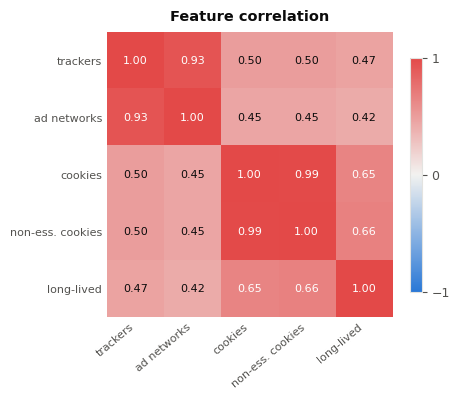

In [19]:
num = ['tracker_count', 'ad_network_count', 'cookies_before_interaction',
       'non_essential_cookies_before_interaction', 'long_lived_cookies_count']
short = ['trackers', 'ad networks', 'cookies', 'non-ess. cookies', 'long-lived']
corr = df_model[num].corr()

fig, ax = plt.subplots(figsize=(4.6, 3.8))
dv = matplotlib.colors.LinearSegmentedColormap.from_list('dv', [BLUE, '#f2f2f0', RED])
im = ax.imshow(corr, cmap=dv, vmin=-1, vmax=1)

ax.set_xticks(range(len(short))); ax.set_xticklabels(short, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(short))); ax.set_yticklabels(short, fontsize=8)

for i in range(len(short)):
    for j in range(len(short)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(v) > .6 else INK)

ax.set_title('Feature correlation', pad=8)
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(length=0)
fig.colorbar(im, ax=ax, shrink=.8, ticks=[-1, 0, 1])
save(fig, 'f04_correlation')

# Charts from the SQL layer

These don't come from `df_model` — they read the CSVs I exported from the 10 SQL
queries in `06_sql_insight_queries.sql`. I chart them here so every figure in the
report is generated from one place instead of scattered across notebooks.

In [20]:
SQLDIR = '../clean_data/sql_query_exports'

q1  = pd.read_csv(f'{SQLDIR}/reject_button_compliance.csv')
q2  = pd.read_csv(f'{SQLDIR}/cmp_popularity.csv')
q3  = pd.read_csv(f'{SQLDIR}/cmp_vs_tracker_comparison.csv')
q4  = pd.read_csv(f'{SQLDIR}/privacy_policy_by_region.csv')
q5  = pd.read_csv(f'{SQLDIR}/tracker_count_by_country.csv')
q6  = pd.read_csv(f'{SQLDIR}/hosting_vs_trackers.csv')
q7  = pd.read_csv(f'{SQLDIR}/top10_highest_tracker_sites.csv')
q8  = pd.read_csv(f'{SQLDIR}/tracker_categories_overview.csv')
q10 = pd.read_csv(f'{SQLDIR}/cmp_vs_tech_bigquery.csv')

print('loaded all query exports')

loaded all query exports


## Figure 5 - Banners with no way to refuse (Query 1)

My headline number.

saved f05_reject_availability


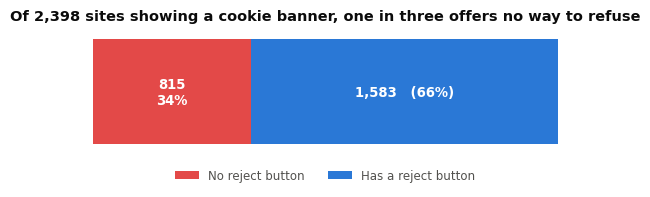

In [21]:
with_btn = int(q1.loc[q1['has_reject_button'] == 1, 'num_sites'].iloc[0])
without  = int(q1.loc[q1['has_reject_button'] == 0, 'num_sites'].iloc[0])
tot1 = with_btn + without

fig, ax = plt.subplots(figsize=(6.0, 1.5))
ax.barh([0], [without], color=RED, height=.55, label='No reject button')
ax.barh([0], [with_btn], left=[without], color=BLUE, height=.55, label='Has a reject button')

ax.text(without / 2, 0, f'{without:,}\n{without/tot1*100:.0f}%', ha='center',
        va='center', color='white', fontsize=9.5, fontweight='bold')
ax.text(without + with_btn / 2, 0, f'{with_btn:,}   ({with_btn/tot1*100:.0f}%)',
        ha='center', va='center', color='white', fontsize=9.5, fontweight='bold')

ax.set_xlim(0, tot1); ax.set_yticks([]); ax.set_xticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title(f'Of {tot1:,} sites showing a cookie banner, one in three offers no way to refuse', pad=10)
ax.legend(loc='upper center', bbox_to_anchor=(.5, -.08), ncol=2, frameon=False,
          fontsize=8.5, labelcolor=INK2)
save(fig, 'f05_reject_availability')

## Figure 6 - CMP market share (Query 2)

Dropping the `none` row — it's 2,458 sites and would flatten everything else to
nothing. Saying so in the title so it isn't a hidden edit.

saved f06_cmp_market_share


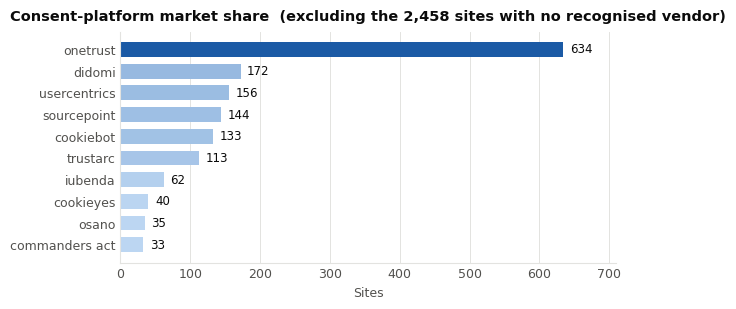

In [22]:
share = q2[q2['cmp_name'] != 'none'].head(10).sort_values('num_sites')
n_none = int(q2.loc[q2['cmp_name'] == 'none', 'num_sites'].iloc[0])

fig, ax = plt.subplots(figsize=(6.4, 3.0))
shade = (share['num_sites'] - share['num_sites'].min()) / max(share['num_sites'].max() - share['num_sites'].min(), 1e-9)
bars = ax.barh(share['cmp_name'], share['num_sites'], color=[RAMP(v) for v in shade], height=.68)
label_h(ax, bars, share['num_sites'].values, '{:,.0f}')

ax.set_xlabel('Sites')
ax.set_title(f'Consent-platform market share  (excluding the {n_none:,} sites with no recognised vendor)', pad=8)
ax.set_xlim(0, share['num_sites'].max() * 1.12)
style(ax, xgrid=True)
save(fig, 'f06_cmp_market_share')

## Figure 7 - Does a CMP mean less tracking? Asked twice (Queries 3 and 10)

The most important chart I have. Left is my scraper, right is BigQuery — two
instruments, two samples, same answer. Two panels rather than one combined chart
because the units are different (counts vs percentages), and putting different
units on one axis would be misleading.

saved f07_cmp_crossvalidation


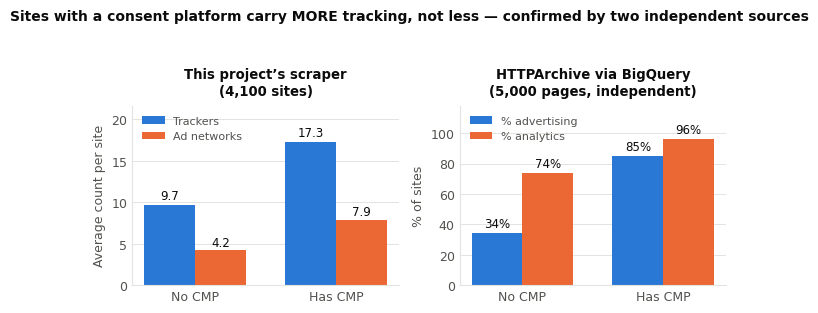

In [23]:
q3i  = q3.set_index('cmp_status').reindex(['No recognized CMP', 'Has recognized CMP'])
q10i = q10.set_index('cmp_status').reindex(['No CMP', 'Has CMP'])

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.9))
x, w = np.arange(2), .36

a = axes[0]
b1 = a.bar(x - w/2, q3i['avg_trackers'], w, color=BLUE, label='Trackers')
b2 = a.bar(x + w/2, q3i['avg_ad_networks'], w, color=ORANGE, label='Ad networks')
label_v(a, b1, q3i['avg_trackers'].values, '{:.1f}')
label_v(a, b2, q3i['avg_ad_networks'].values, '{:.1f}')
a.set_xticks(x); a.set_xticklabels(['No CMP', 'Has CMP'])
a.set_ylabel('Average count per site')
a.set_title('This project’s scraper\n(4,100 sites)', fontsize=9.5, pad=8)
a.legend(frameon=False, fontsize=8, labelcolor=INK2)
a.set_ylim(0, q3i['avg_trackers'].max() * 1.25)
style(a, ygrid=True)

a = axes[1]
b1 = a.bar(x - w/2, q10i['pct_with_advertising'], w, color=BLUE, label='% advertising')
b2 = a.bar(x + w/2, q10i['pct_with_analytics'], w, color=ORANGE, label='% analytics')
label_v(a, b1, q10i['pct_with_advertising'].values, '{:.0f}%')
label_v(a, b2, q10i['pct_with_analytics'].values, '{:.0f}%')
a.set_xticks(x); a.set_xticklabels(['No CMP', 'Has CMP'])
a.set_ylabel('% of sites')
a.set_title('HTTPArchive via BigQuery\n(5,000 pages, independent)', fontsize=9.5, pad=8)
a.legend(frameon=False, fontsize=8, labelcolor=INK2)
a.set_ylim(0, 118)
style(a, ygrid=True)

fig.suptitle('Sites with a consent platform carry MORE tracking, not less — confirmed by two independent sources',
             fontsize=10, fontweight='bold', y=1.06)
fig.tight_layout()
save(fig, 'f07_cmp_crossvalidation')

## Figure 8 - Is my scraper measuring the same thing as BigQuery? (Query 9)

Instrument check. 40% vs 28.7% — the gap is expected, because my scraper also
catches custom banners that Wappalyzer-style detection doesn't fingerprint.

saved f13_detection_rate_check


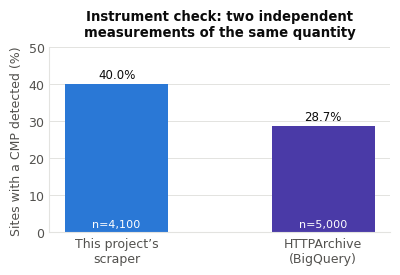

In [24]:
fig, ax = plt.subplots(figsize=(4.4, 2.4))
bars = ax.bar(['This project’s\nscraper', 'HTTPArchive\n(BigQuery)'], [40.0, 28.7],
              width=.5, color=[BLUE, VIOLET])
label_v(ax, bars, [40.0, 28.7], '{:.1f}%')

for b, n in zip(bars, ['n=4,100', 'n=5,000']):
    ax.text(b.get_x() + b.get_width()/2, 1.5, n, ha='center', fontsize=8, color='white')

ax.set_ylabel('Sites with a CMP detected (%)')
ax.set_title('Instrument check: two independent\nmeasurements of the same quantity', pad=8, fontsize=9.5)
ax.set_ylim(0, 50)
style(ax, ygrid=True)
save(fig, 'f13_detection_rate_check')

## Figure 9 - Privacy policy by region (Query 4)

saved f08_privacy_policy_region


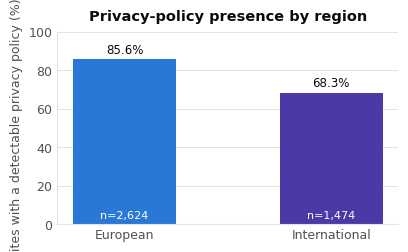

In [25]:
fig, ax = plt.subplots(figsize=(4.4, 2.5))
bars = ax.bar(q4['region'], q4['pct_with_policy'], width=.5, color=[BLUE, VIOLET])
label_v(ax, bars, q4['pct_with_policy'].values, '{:.1f}%')

for b, n in zip(bars, q4['num_sites']):
    ax.text(b.get_x() + b.get_width()/2, 3, f'n={n:,}', ha='center', fontsize=8, color='white')

ax.set_ylim(0, 100)
ax.set_ylabel('Sites with a detectable privacy policy (%)')
ax.set_title('Privacy-policy presence by region', pad=8)
style(ax, ygrid=True)
save(fig, 'f08_privacy_policy_region')

## Figure 10 - Trackers by market (Query 5)

Only countries I could infer from the domain suffix, so this leans toward sites
with a national TLD and drops most .com domains.

saved f09_trackers_by_country


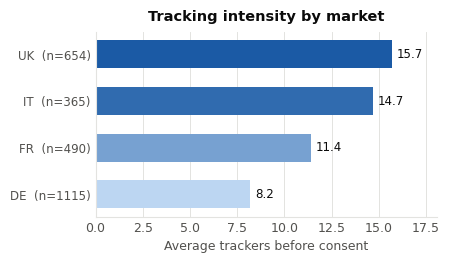

In [26]:
c = q5.sort_values('avg_trackers')

fig, ax = plt.subplots(figsize=(4.4, 2.4))
shade = (c['avg_trackers'] - c['avg_trackers'].min()) / max(c['avg_trackers'].max() - c['avg_trackers'].min(), 1e-9)
bars = ax.barh(range(len(c)), c['avg_trackers'], color=[RAMP(v) for v in shade], height=.6)
label_h(ax, bars, c['avg_trackers'].values, '{:.1f}')

ax.set_yticks(range(len(c)))
ax.set_yticklabels([f'{k}  (n={int(n)})' for k, n in zip(c['country'], c['num_sites'])], fontsize=8.5)
ax.set_xlabel('Average trackers before consent')
ax.set_title('Tracking intensity by market', pad=8)
ax.set_xlim(0, c['avg_trackers'].max() * 1.15)
style(ax, xgrid=True)
save(fig, 'f09_trackers_by_country')

## Figure 11 - Hosting type vs trackers (Query 6)

Dropping the 6 rows where `is_hosting` is NULL — too few to plot meaningfully.

saved f10_hosting_vs_trackers


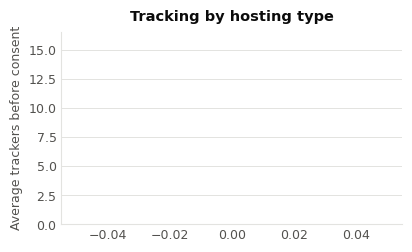

In [27]:
h = q6[q6['is_hosting'].isin(['1', '0', 1, 0])].copy()
h['label'] = h['is_hosting'].astype(str).map({'1': 'Cloud / hosting\nprovider', '0': 'Self-hosted'})
h = h.sort_values('avg_trackers')

fig, ax = plt.subplots(figsize=(4.4, 2.5))
bars = ax.bar(h['label'], h['avg_trackers'], width=.5, color=[BLUE, VIOLET])
label_v(ax, bars, h['avg_trackers'].values, '{:.1f}')

for b, n in zip(bars, h['num_sites']):
    ax.text(b.get_x() + b.get_width()/2, .5, f'n={int(n):,}', ha='center', fontsize=8, color='white')

ax.set_ylabel('Average trackers before consent')
ax.set_title('Tracking by hosting type', pad=8)
ax.set_ylim(0, h['avg_trackers'].max() * 1.2)
style(ax, ygrid=True)
save(fig, 'f10_hosting_vs_trackers')

## Figure 12 - The ten worst offenders (Query 7)

Split into ad networks vs everything else, because for most of these the majority
of the load is advertising. Vendor name printed next to the total where there is
one.

saved f11_top10_sites


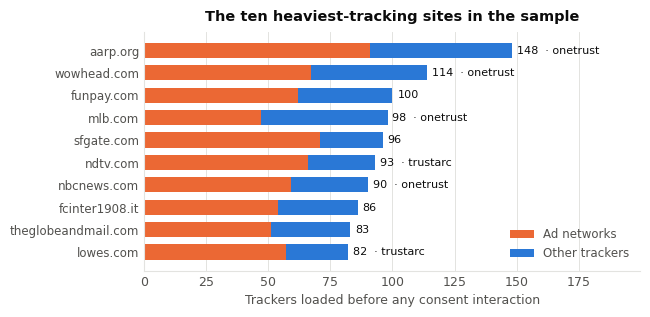

In [28]:
t = q7.sort_values('tracker_count')
other = t['tracker_count'] - t['ad_network_count']

fig, ax = plt.subplots(figsize=(6.4, 3.1))
ax.barh(t['domain_name'], t['ad_network_count'], color=ORANGE, height=.68, label='Ad networks')
ax.barh(t['domain_name'], other, left=t['ad_network_count'], color=BLUE, height=.68, label='Other trackers')

for y, (total, vendor) in enumerate(zip(t['tracker_count'], t['cmp_name'])):
    tag = '' if str(vendor) == 'none' else f'  · {vendor}'
    ax.text(total + 2, y, f'{total}{tag}', va='center', fontsize=8, color=INK)

ax.set_xlim(0, t['tracker_count'].max() * 1.35)
ax.set_xlabel('Trackers loaded before any consent interaction')
ax.set_title('The ten heaviest-tracking sites in the sample', pad=8)
ax.legend(frameon=False, fontsize=8.5, labelcolor=INK2, loc='lower right')
ax.tick_params(axis='y', labelsize=8.5)
style(ax, xgrid=True)
save(fig, 'f11_top10_sites')

## Figure 13 - The tracker catalogue by category (Query 8)

Context rather than a finding about my sites — this describes the Disconnect.me
list I'm matching against.

saved f12_tracker_categories

all report figures regenerated


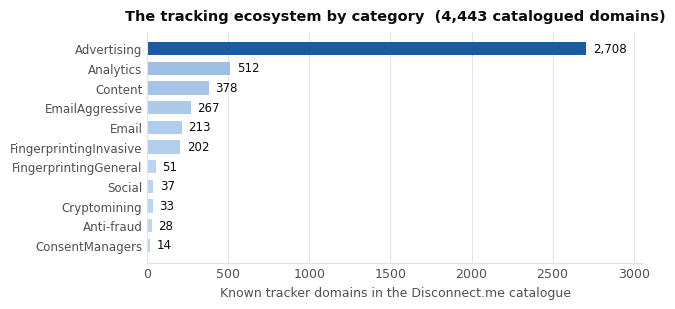

In [29]:
cat = q8.sort_values('num_known_trackers')

fig, ax = plt.subplots(figsize=(6.4, 3.0))
shade = (cat['num_known_trackers'] - cat['num_known_trackers'].min()) / max(cat['num_known_trackers'].max() - cat['num_known_trackers'].min(), 1e-9)
bars = ax.barh(cat['category'], cat['num_known_trackers'], color=[RAMP(v) for v in shade], height=.68)
label_h(ax, bars, cat['num_known_trackers'].values, '{:,.0f}')

ax.set_xlabel('Known tracker domains in the Disconnect.me catalogue')
ax.set_title(f'The tracking ecosystem by category  ({cat["num_known_trackers"].sum():,} catalogued domains)', pad=8)
ax.set_xlim(0, cat['num_known_trackers'].max() * 1.13)
ax.tick_params(axis='y', labelsize=8.5)
style(ax, xgrid=True)
save(fig, 'f12_tracker_categories')

print('\nall report figures regenerated')

# Save the ML-ready dataset (reject-effectiveness model)

## trimmed feature set + target + id columns
Dropped ad_network_count (0.93 correlated with tracker_count) and
cookies_before_interaction (0.99 correlated with non_essential_cookies_before_interaction).

In [30]:
final_cols = [
    'url', 'domain',
    'cmp_detected',
    'tracker_count',
    'non_essential_cookies_before_interaction',
    'long_lived_cookies_count',
    'has_privacy_policy',
    'is_hosting',
    'uses_major_cloud_cdn',
    'reject_works'
]

final_cols = [c for c in final_cols if c in df_model.columns]
df_final = df_model[final_cols].copy()

print('Final shape:', df_final.shape)
print('Columns:', df_final.columns.tolist())
df_final.head()

Final shape: (1583, 10)
Columns: ['url', 'domain', 'cmp_detected', 'tracker_count', 'non_essential_cookies_before_interaction', 'long_lived_cookies_count', 'has_privacy_policy', 'is_hosting', 'uses_major_cloud_cdn', 'reject_works']


,url,domain,cmp_detected,tracker_count,non_essential_cookies_before_interaction,long_lived_cookies_count,has_privacy_policy,is_hosting,uses_major_cloud_cdn,reject_works
0,https://telekom.de,telekom.de,none,3.0,5.0,0.0,True,True,False,False
2,https://bbc.co.uk,bbc.co.uk,none,25.0,16.0,6.0,True,True,True,False
3,https://www.gov.uk,gov.uk,none,4.0,1.0,0.0,True,NaN,False,True
4,https://amazon.co.uk,amazon.co.uk,cookie notice,8.0,10.0,0.0,True,True,True,True
5,https://dailymail.co.uk,dailymail.co.uk,trustarc,30.0,15.0,4.0,True,False,True,False


In [31]:
df_final.to_csv('../clean_data/final_model_data_ready_to_train.csv', index=False)
print(f'Saved csv — {df_final.shape}')

Saved csv — (1583, 10)
